In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/ForeignGifts_edu.csv")

df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [5]:
df['Gift Type'].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

B) The different classes of gift types are contracts, monetary gifts and real estate.

In [71]:
country_total_don = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)

country_total_don.head(15)

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

a) Qatar gives the most money in total.

In [52]:
country_count_don = df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False)

country_count_don.head(15)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

b) England initiates the most gifts by count.

In [13]:
country_avg_don = df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending=False)

country_avg_don

Country of Giftor
BERMUDA      7.688837e+06
ECUADOR      3.985140e+06
QATAR        3.905109e+06
ANTIGUA      3.435545e+06
JERSEY       3.064589e+06
                 ...     
ST. LUCIA    5.000000e+01
IRAN         4.000000e+01
CROATIA      2.600000e+01
SLOVAKIA     2.000000e+01
ERITREA      3.000000e+00
Name: Foreign Gift Amount, Length: 155, dtype: float64

c) Bermuda gives the largest gifts on average.

In [22]:
uni_total_don = df.groupby('Institution Name')['Foreign Gift Amount'].sum().reset_index().sort_values(by='Foreign Gift Amount', ascending=False)

uni_total_don.head(20)

,Institution Name,Foreign Gift Amount
45,Carnegie Mellon University,1477922504
62,Cornell University,1289937761
87,Harvard University,954803610
114,Massachusetts Institute of Technology,859071692
315,Yale University,613441311
185,Texas A&M University,521455050
99,Johns Hopkins University,502409595
143,Northwestern University,402316221
81,Georgetown University,379950511
209,University of Chicago (The),364544338


d) Carnegie Mellon receives the most money in total.

In [7]:
uni_count_don = df.groupby('Institution Name')['Foreign Gift Amount'].count().sort_values(ascending=False)

uni_count_don.head(20)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
University of Michigan - Ann Arbor              715
Stanford University                             668
Cornell University                              653
University of Pennsylvania                      625
Massachusetts Institute of Technology           582
Yale University                                 550
Harvard University                              453
University of Colorado Denver                   436
University of Chicago (The)                     401
Arizona State University                        400
University of California, Berkeley              394
Colorado State University                       379
University of Texas at Austin                   377
Texas A&M University                           

e) UCLA receives the highest number of gifts.

<Axes: xlabel='Foreign Gift Amount', ylabel='Institution Name'>

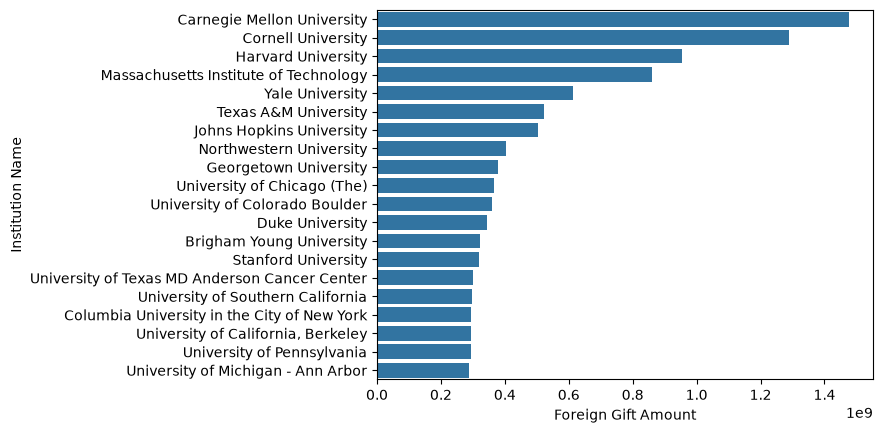

In [48]:
sns.barplot(data=uni_total_don.head(20), x='Foreign Gift Amount', y='Institution Name')

Calculate the mean and median of how much colleges are receiving in donations:

In [69]:
mean_total_don = uni_total_don['Foreign Gift Amount'].mean()

median_total_don = uni_total_don['Foreign Gift Amount'].median()

mean_total_don, median_total_don

(np.float64(52202878.974842764), np.float64(6486791.5))

f) The mean amount each university receives is: $52,202,878.97 while the median is $6,486,791.5.

The reason the median is so much smaller than the mean is because the majority of universities receive a small (relatively) amount of $ in foreign donations. The mean is skewed up by a small number of universities receiving massive foreign donations. This is visually shown by the histogram below.

Create a histogram with the mean and median as vertical lines:

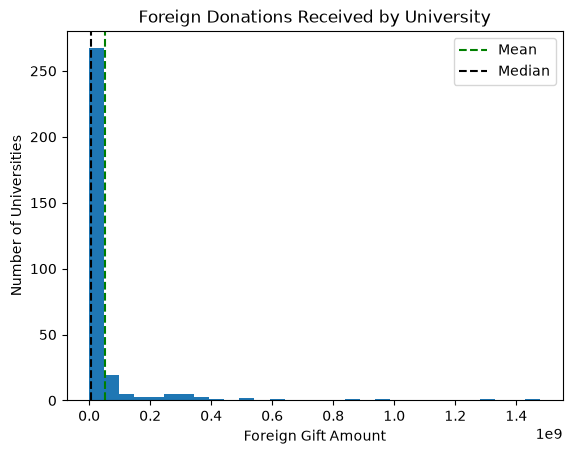

In [65]:
plt.hist(uni_total_don['Foreign Gift Amount'], bins=30)
plt.axvline(mean_total_don, linestyle='--', color= 'g', label='Mean')
plt.axvline(median_total_don, linestyle='--', color= 'k', label='Median')
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Number of Universities')
plt.title('Foreign Donations Received by University')
plt.legend()

plt.show()

g) Using an alluvial plot to determine the largest flow of a single country to a single institution:

In [34]:
import plotly.graph_objects as go

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

g) Based on the alluvial plot, the largest flow of money from a country to a university is Qatar to Cornell.

h) The top giftors to US academic institutions are listed below:

In [49]:
giftor_total_don = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)

giftor_total_don.head(20)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Sanofi-Aventis Recerche                  62106706
Saudi Arabia                             59450098
Sanofi-Aventis Recherche                 58520202
Skolkovo Foundation                      51500000
Stavros S. Niarchos Foundation        

Bonus: Plotting the flows from giftors to institutions:

In [68]:
giftor_name = 'Giftor Name'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor_name, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor_name].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig2 = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor_name]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig2.show()